In [ ]:
# Manipulation de données
import numpy as np
import pandas as pd

# Normalisation des données
from sklearn.preprocessing import StandardScaler

# Algorithmes de clustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from kneed import KneeLocator
from collections import Counter

# Métriques d’évaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Visualisation (2D/Elbow/Dendrogramme)
import matplotlib.pyplot as plt
import seaborn as sns

# Optionnel : pour affichage 3D
from mpl_toolkits.mplot3d import Axes3D  # si tu veux faire des nuages de points 3D

lire fichier ( csv ou trff ) et retourner 2 choses ( df:data et data: data normalisés )

In [6]:
def load_dataset(file_path, normalize=True):
    """
    Charge un fichier CSV ou .trff et retourne un DataFrame (et un tableau normalisé si demandé).
    
    Paramètres :
    - file_path : chemin du fichier
    - normalize : bool, True pour renvoyer aussi les données normalisées
    
    Retourne :
    - df : DataFrame original
    - data : tableau numpy normalisé ou non
    """
    # Détecter l'extension
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    elif file_path.endswith('.trff'):
        df = pd.read_csv(file_path, delimiter='\t')  # fichier texte tabulé
    else:
        raise ValueError("Format de fichier non supporté. Utilisez .csv ou .trff")
    
    # Option : supprimer les colonnes non numériques (si présentes)
    df_numeric = df.select_dtypes(include=['float64', 'int64'])

    if normalize:
        scaler = StandardScaler()
        data = scaler.fit_transform(df_numeric.values)
    else:
        data = df_numeric.values

    return df, data

tracage de courb d'elbow :

In [9]:
def plot_elbow_curve(data, max_k=10):
    """
    Trace la courbe d'Elbow pour déterminer le nombre optimal de clusters.
    
    Paramètres :
    - data : données normalisées (numpy array)
    - max_k : nombre maximum de clusters à tester

    Affiche :
    - La courbe d'inertie (distorsion intra-cluster)
    """
    inertias = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

    # Tracé
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inertias, marker='o', linestyle='-', color='blue')
    plt.title("Méthode du Coude (Elbow Method)")
    plt.xlabel("Nombre de clusters (k)")
    plt.ylabel("Inertie (Within-Cluster Sum of Squares)")
    plt.grid(True)
    plt.show()

fonction pour explorer les données 

In [14]:
def explore_dataset(df):
    """
    Affiche un résumé utile de la structure d'un DataFrame :
    - les premières lignes
    - la forme
    - les types de données
    - les valeurs manquantes
    - les statistiques descriptives
    
    Paramètre :
    - df : le DataFrame à explorer
    """
    print("🔹 Aperçu des 5 premières lignes :")
    print(df.head())
    print("\n🔹 Dimensions du dataset :", df.shape)
    print("\n🔹 Types de données :")
    print(df.dtypes)
    print("\n🔹 Valeurs manquantes par colonne :")
    print(df.isnull().sum())
    print("\n🔹 Statistiques descriptives (colonnes numériques) :")
    print(df.describe())


fonction pour tracer les boxplots 

In [16]:
def plot_boxplots(data, columns=None):
    """
    Affiche les boxplots pour chaque colonne du jeu de données normalisé.

    Paramètres :
    - data : données normalisées (numpy array ou DataFrame)
    - columns : noms des colonnes (si data est un numpy array)
    """
    # Si data est un array NumPy, le convertir en DataFrame pour tracer
    if not isinstance(data, pd.DataFrame):
        if columns is None:
            columns = [f"Var{i+1}" for i in range(data.shape[1])]
        data = pd.DataFrame(data, columns=columns)

    # Tracer les boxplots
    plt.figure(figsize=(12, 6))
    data.boxplot()
    plt.title("Boxplots des variables (normalisées)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

selectionne deux colonne pour tracer scatter plot

In [21]:
def select_and_plot_scatter(data, columns=None):
    """
    Affiche la liste des colonnes disponibles et demande à l'utilisateur de choisir deux colonnes.
    Trace ensuite un scatter plot entre les deux colonnes choisies.

    Paramètres :
    - data : array numpy ou DataFrame
    - columns : noms des colonnes (si data est un array)
    """
    # Convertir en DataFrame si ce n’est pas déjà le cas
    if not isinstance(data, pd.DataFrame):
        if columns is None:
            columns = [f"Var{i+1}" for i in range(data.shape[1])]
        data = pd.DataFrame(data, columns=columns)

    # Afficher les colonnes disponibles
    print("📊 Colonnes disponibles :")
    for i, col in enumerate(data.columns):
        print(f"{i}: {col}")

    # Demander à l'utilisateur de choisir deux colonnes
    try:
        idx1 = int(input("👉 Entrez l'indice de la 1ère colonne à tracer : "))
        idx2 = int(input("👉 Entrez l'indice de la 2ème colonne à tracer : "))
    except ValueError:
        print("❌ Entrée invalide. Veuillez entrer un nombre.")
        return

    col1 = data.columns[idx1]
    col2 = data.columns[idx2]

    # Tracer le scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(data[col1], data[col2], c='blue', edgecolor='k')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"Scatter Plot entre {col1} et {col2}")
    plt.grid(True)
    plt.show()

K-MEAN

In [30]:
def apply_kmeans_show_classes(df, data, n_clusters, class_col_candidates=['Classe', 'Species', 'target']):
    """
    Applique K-Means sur les données normalisées, affiche la visualisation et ajoute la vraie classe si disponible.

    Paramètres :
    - df : DataFrame original (non normalisé, contient potentiellement la classe)
    - data : données normalisées (array ou DataFrame sans la classe)
    - n_clusters : nombre de clusters
    - class_col_candidates : liste des noms possibles de la colonne contenant les vraies classes

    Retour :
    - df_clustered : DataFrame contenant les données, les clusters, et la classe réelle (si trouvée)
    """
    # Convertir en DataFrame si data est un array
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=df.select_dtypes(include=['float64', 'int64']).columns)

    # Appliquer KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data)

    # Création du DataFrame final
    df_clustered = data.copy()
    df_clustered["Cluster"] = labels

    # Chercher une colonne de classe dans le DataFrame original
    for col in class_col_candidates:
        if col in df.columns:
            df_clustered["Classe"] = df[col].values
            break  # on ajoute la première trouvée

    # Affichage : scatter plot sur les 2 premières dimensions
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels, cmap='viridis', edgecolor='k', label='Clusters')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', s=200, marker='X', label='Centroïdes')
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.title(f"K-Means Clustering (k={n_clusters})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_clustered

evaluer le clustering

In [35]:
def evaluate_clustering_metrics(data, labels):
    """
    Calcule et affiche le coefficient de silhouette.

    Paramètres :
    - data : données normalisées (array ou DataFrame)
    - labels : labels de clustering (liste ou array)

    Retour :
    - silhouette : score entre -1 et 1
    """
    silhouette = silhouette_score(data, labels)
    print(f"🟩 Coefficient de Silhouette : {silhouette:.3f}")
    return silhouette

In [ ]:
di,dn=load_dataset('breast(1).csv')
result = apply_kmeans_show_classes(di, dn, n_clusters=3)
evaluate_clustering_metrics(dn, result["Cluster"])


evaluation

In [37]:
def compute_clustering_metrics(data, labels, display=True):
    """
    Calcule et affiche les principales métriques de qualité pour un clustering.

    Paramètres :
    - data : données normalisées (numpy array ou DataFrame)
    - labels : labels prédits (array)
    - display : bool, si True, affiche les résultats

    Retour :
    - metrics_dict : dictionnaire contenant les scores
    """
    metrics_dict = {}

    metrics_dict["Silhouette Score"] = silhouette_score(data, labels)
    metrics_dict["Davies-Bouldin Index"] = davies_bouldin_score(data, labels)
    metrics_dict["Calinski-Harabasz Index"] = calinski_harabasz_score(data, labels)

    if display:
        print("📊 Métriques de Clustering :")
        for key, value in metrics_dict.items():
            print(f"  - {key}: {value:.3f}")

    return metrics_dict

agnes avec dendogramme

In [54]:
def apply_agnes_and_plot_dendrogram(data, n_clusters=3, method='ward'):
    """
    Applique AGNES et affiche le dendrogramme avec une ligne de coupe.

    Paramètres :
    - data : numpy array normalisé
    - n_clusters : nombre de clusters à créer
    - method : méthode de linkage ('ward', 'single', 'complete', 'average')

    Retour :
    - labels : clusters assignés
    """
    # 1. Créer la matrice de liaison
    linked = linkage(data, method=method)

    # 2. Tracer le dendrogramme
    plt.figure(figsize=(10, 5))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    
    # 🔴 Ajouter la ligne de coupe correspondant au nombre de clusters
    max_d = linked[-(n_clusters - 1), 2]  # Hauteur où les derniers clusters fusionnent
    plt.axhline(y=max_d, color='red', linestyle='--', label=f'{n_clusters} clusters')
    plt.legend()

    plt.title(f"Dendrogramme AGNES (méthode = {method})")
    plt.xlabel("Index des points")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # 3. Clustering
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    labels = model.fit_predict(data)

    return labels

DIANA

In [62]:
def diana_clustering(data, n_clusters=3):
    """
    Implémentation de l'algorithme DIANA (DIvisive ANAlysis Clustering).
    
    Paramètres:
    - data: numpy array normalisé
    - n_clusters: nombre de clusters à créer
    
    Retour:
    - labels: clusters assignés (array de taille data.shape[0])
    """
    n_samples = data.shape[0]
    
    # Initialiser avec tous les points dans un seul cluster
    current_labels = np.zeros(n_samples, dtype=int)
    
    # Liste pour suivre les clusters à diviser
    clusters_to_process = [np.arange(n_samples)]
    
    # Continuer jusqu'à obtenir le nombre souhaité de clusters
    next_label = 1
    
    while len(clusters_to_process) < n_clusters:
        # Choisir le cluster avec la plus grande dispersion
        max_dispersion = -1
        selected_cluster_idx = -1
        
        for i, cluster_indices in enumerate(clusters_to_process):
            if len(cluster_indices) <= 1:
                continue  # Ne pas diviser les clusters avec un seul point
                
            # Calculer la matrice de distance pour ce cluster
            cluster_data = data[cluster_indices]
            dist_matrix = squareform(pdist(cluster_data, metric='euclidean'))
            
            # Calculer la dispersion (somme des distances intra-cluster)
            dispersion = np.sum(dist_matrix) / 2  # Diviser par 2 car la matrice est symétrique
            
            if dispersion > max_dispersion:
                max_dispersion = dispersion
                selected_cluster_idx = i
        
        if selected_cluster_idx == -1:
            break  # Aucun cluster divisible trouvé
        
        # Diviser le cluster sélectionné
        cluster_to_split = clusters_to_process[selected_cluster_idx]
        cluster_data = data[cluster_to_split]
        
        if len(cluster_to_split) <= 2:
            # Si le cluster n'a que 2 points, simplement les séparer
            splitter_a = [cluster_to_split[0]]
            splitter_b = cluster_to_split[1:]
        else:
            # Trouver le point le plus éloigné du centre
            center = np.mean(cluster_data, axis=0)
            distances_to_center = np.linalg.norm(cluster_data - center, axis=1)
            splitter_idx = np.argmax(distances_to_center)
            
            # Initialiser les deux sous-clusters
            splitter_a = [cluster_to_split[splitter_idx]]
            splitter_b = [idx for i, idx in enumerate(cluster_to_split) if i != splitter_idx]
            
            # Réaffecter les points en fonction de leur similitude
            changes = True
            while changes and len(splitter_b) > 0:
                changes = False
                
                # Calculer les distances moyennes de chaque point au splitter_a
                subset_a = data[splitter_a]
                subset_b = data[splitter_b]
                
                # Pour chaque point dans splitter_b, vérifier s'il devrait être déplacé vers splitter_a
                for i, point_idx in enumerate(splitter_b[:]):
                    point = data[point_idx].reshape(1, -1)
                    
                    if len(splitter_a) == 0:
                        continue
                        
                    # Calculer la distance moyenne au groupe A
                    avg_dist_a = np.mean(np.linalg.norm(subset_a - point, axis=1))
                    
                    # Calculer la distance moyenne au reste du groupe B
                    remaining_b = np.delete(subset_b, i, axis=0)
                    if len(remaining_b) > 0:
                        avg_dist_b = np.mean(np.linalg.norm(remaining_b - point, axis=1))
                    else:
                        avg_dist_b = float('inf')  # Si B est vide, considérer comme distance infinie
                    
                    # Si le point est plus proche du groupe A, le déplacer
                    if avg_dist_a < avg_dist_b:
                        splitter_a.append(point_idx)
                        splitter_b.remove(point_idx)
                        subset_a = data[splitter_a]
                        subset_b = data[splitter_b] if splitter_b else np.array([])
                        changes = True
                        break  # Recommencer le processus
        
        # Mettre à jour les labels
        current_labels[splitter_a] = next_label
        next_label += 1
        
        # Mettre à jour la liste des clusters
        clusters_to_process.pop(selected_cluster_idx)
        clusters_to_process.append(np.array(splitter_a))
        clusters_to_process.append(np.array(splitter_b))
    
    return current_labels

def visualize_diana_clustering(data, n_clusters=3):
    """
    Applique l'algorithme DIANA et visualise les clusters.
    
    Paramètres:
    - data: numpy array normalisé
    - n_clusters: nombre de clusters à créer
    
    Retourne:
    - labels: résultat du clustering
    """
    # Appliquer DIANA
    labels = diana_clustering(data, n_clusters)
    
    # Visualiser les clusters en 2D
    plot_clusters_2d(data, labels, title=f"DIANA Clustering avec {n_clusters} clusters")
    
    # Afficher la distribution des points par cluster
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"Distribution des points par cluster:")
    for label, count in zip(unique_labels, counts):
        print(f"Cluster {label}: {count} points")
    
    return labels

def plot_clusters_2d(data, labels, title="Visualisation des clusters"):
    """
    Visualise les clusters en 2D après réduction dimensionnelle.
    
    Paramètres:
    - data: données originales
    - labels: étiquettes de clusters
    - title: titre du graphique
    """
    # Réduction dimensionnelle avec PCA si nécessaire
    if data.shape[1] > 2:
        pca = PCA(n_components=2)
        data_2d = pca.fit_transform(data)
        explained_var = pca.explained_variance_ratio_
        print(f"Variance expliquée par les 2 premières composantes: {sum(explained_var)*100:.2f}%")
    else:
        data_2d = data
    
    # Obtenir le nombre de clusters uniques
    n_clusters = len(np.unique(labels))
    
    # Définir une palette de couleurs
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    # Tracer les points
    plt.figure(figsize=(10, 8))
    for i, color in zip(range(n_clusters), colors):
        cluster_points = data_2d[labels == i]
        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            s=50, c=[color], 
            label=f'Cluster {i}'
        )
    
    plt.title(title, fontsize=15)
    plt.xlabel("Composante 1" if data.shape[1] > 2 else "Dimension 1")
    plt.ylabel("Composante 2" if data.shape[1] > 2 else "Dimension 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

DBASCAN

In [73]:
def plot_k_distance_graph(data, k=4, n_points=None):
    """
    Trace le graphique de la k-distance avec suggestions d'epsilon multiples.
    
    Paramètres :
    - data : numpy array normalisé
    - k : nombre de voisins (MinPts - 1)
    - n_points : nombre de points à afficher (None pour tous)
    
    Retourne :
    - eps_suggestions : liste de suggestions de valeurs pour eps
    """
    # Calcul des distances aux k voisins les plus proches
    neighbors = NearestNeighbors(n_neighbors=k+1).fit(data)
    distances, _ = neighbors.kneighbors(data)
    
    # Trier les distances au k-ième voisin
    k_distances = np.sort(distances[:, k])
    
    # Limiter le nombre de points si spécifié
    if n_points and n_points < len(k_distances):
        indices = np.linspace(0, len(k_distances)-1, n_points, dtype=int)
        k_distances_display = k_distances[indices]
    else:
        k_distances_display = k_distances
    
    # Tracer le graphique de la k-distance
    plt.figure(figsize=(12, 7))
    plt.plot(range(len(k_distances_display)), k_distances_display, 'b-')
    plt.xlabel('Points triés par distance')
    plt.ylabel(f'Distance au {k}ème voisin le plus proche')
    plt.title(f'Graphique de la {k}-distance pour déterminer epsilon')
    plt.grid(True)
    
    # Trouver plusieurs suggestions d'epsilon
    eps_suggestions = []
    
    # 1. Détection automatique du coude principal
    try:
        kneedle = KneeLocator(range(len(k_distances)), k_distances, 
                             curve='convex', direction='increasing')
        knee_index = kneedle.knee
        if knee_index:
            eps_knee = k_distances[knee_index]
            eps_suggestions.append(eps_knee)
            plt.axvline(x=knee_index if n_points is None else knee_index * n_points // len(k_distances), 
                       color='r', linestyle='--', 
                       label=f'Coude principal à eps ≈ {eps_knee:.4f}')
            plt.axhline(y=eps_knee, color='r', linestyle='--')
    except:
        pass
    
    # 2. Ajouter des suggestions basées sur des percentiles de la distribution
    for percentile, color, style in [(10, 'g', '-.'), (25, 'm', ':'), (50, 'c', '--')]:
        eps_perc = np.percentile(k_distances, percentile)
        eps_suggestions.append(eps_perc)
        plt.axhline(y=eps_perc, color=color, linestyle=style, 
                   label=f'Percentile {percentile}% à eps ≈ {eps_perc:.4f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retourner les suggestions triées (du plus petit au plus grand)
    return sorted(eps_suggestions)

def adaptive_dbscan_clustering(data, target_clusters=3, min_pts_range=range(2, 11), max_noise_ratio=0.2):
    """
    Version améliorée de DBSCAN qui adapte les paramètres pour équilibrer les clusters.
    
    Paramètres :
    - data : numpy array normalisé
    - target_clusters : nombre cible de clusters
    - min_pts_range : plage de valeurs à tester pour MinPts
    - max_noise_ratio : ratio maximum de points de bruit acceptables
    
    Retourne :
    - best_labels : meilleures étiquettes de clusters trouvées
    - best_eps : meilleure valeur epsilon
    - best_min_pts : meilleure valeur MinPts
    - best_metrics : dict avec métriques sur la meilleure solution
    """
    best_labels = None
    best_eps = None
    best_min_pts = None
    best_metrics = {
        'n_clusters': 0,
        'silhouette': -1,
        'calinski': -1,
        'noise_ratio': 1.0,
        'cluster_sizes': [],
        'size_std': float('inf')  # Écart-type de la taille des clusters
    }
    
    print("Recherche des paramètres optimaux pour DBSCAN...")
    
    # Essai de plusieurs valeurs de MinPts
    for min_pts in min_pts_range:
        # Obtenir plusieurs suggestions d'epsilon
        eps_suggestions = plot_k_distance_graph(data, k=min_pts-1)
        print(f"\nTest avec MinPts = {min_pts}")
        
        # Ajouter des valeurs intermédiaires entre les suggestions
        additional_eps = []
        for i in range(len(eps_suggestions)-1):
            mid = (eps_suggestions[i] + eps_suggestions[i+1]) / 2
            additional_eps.extend([eps_suggestions[i] * 0.75, mid, eps_suggestions[i+1] * 0.9])
        
        # Combiner toutes les suggestions d'epsilon
        all_eps = sorted(set(eps_suggestions + additional_eps))
        
        # Essayer chaque valeur d'epsilon
        for eps in all_eps:
            # Appliquer DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_pts)
            labels = dbscan.fit_predict(data)
            
            # Compter les clusters (hors bruit)
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            
            # Calculer le ratio de points de bruit
            noise_count = list(labels).count(-1)
            noise_ratio = noise_count / len(labels)
            
            # Si trop de bruit, ignorer cette configuration
            if noise_ratio > max_noise_ratio:
                continue
                
            # Calculer la distribution des tailles de clusters
            cluster_sizes = []
            for label in unique_labels:
                if label != -1:  # Ignorer les points de bruit
                    cluster_sizes.append(list(labels).count(label))
                    
            # Écart-type de la taille des clusters
            size_std = np.std(cluster_sizes) if cluster_sizes else float('inf')
            
            # Si on a un nombre de clusters proche de la cible (±1)
            if abs(n_clusters - target_clusters) <= 1:
                # Calculer les métriques de qualité
                metrics = {
                    'n_clusters': n_clusters,
                    'noise_ratio': noise_ratio,
                    'cluster_sizes': cluster_sizes,
                    'size_std': size_std
                }
                
                # Calculer le score silhouette (si possible)
                if n_clusters > 1:
                    non_noise_indices = labels != -1
                    if sum(non_noise_indices) > n_clusters:
                        try:
                            metrics['silhouette'] = silhouette_score(
                                data[non_noise_indices], labels[non_noise_indices]
                            )
                            metrics['calinski'] = calinski_harabasz_score(
                                data[non_noise_indices], labels[non_noise_indices]
                            )
                        except:
                            metrics['silhouette'] = -1
                            metrics['calinski'] = -1
                
                # Système de score pour sélectionner la meilleure solution
                is_better = False
                
                # Si le nombre exact de clusters est atteint
                if n_clusters == target_clusters and best_metrics['n_clusters'] != target_clusters:
                    is_better = True
                # Si on a le même nombre de clusters que la meilleure solution actuelle
                elif n_clusters == best_metrics['n_clusters']:
                    # Préférer les clusters plus équilibrés (écart-type plus petit)
                    if size_std < best_metrics['size_std'] * 0.8:
                        is_better = True
                    # À équilibre similaire, préférer moins de bruit
                    elif abs(size_std - best_metrics['size_std']) < best_metrics['size_std'] * 0.2:
                        if noise_ratio < best_metrics['noise_ratio'] * 0.8:
                            is_better = True
                        # À bruit similaire, préférer une meilleure séparation des clusters
                        elif abs(noise_ratio - best_metrics['noise_ratio']) < best_metrics['noise_ratio'] * 0.2:
                            if metrics.get('silhouette', -1) > best_metrics.get('silhouette', -1):
                                is_better = True
                
                # Mettre à jour la meilleure solution si nécessaire
                if is_better:
                    best_labels = labels.copy()
                    best_eps = eps
                    best_min_pts = min_pts
                    best_metrics = metrics
                    
                    print(f"Meilleure solution mise à jour: eps={eps:.4f}, MinPts={min_pts}")
                    print(f"  {n_clusters} clusters, {noise_ratio:.1%} de bruit")
                    print(f"  Tailles des clusters: {cluster_sizes}")
                    if 'silhouette' in metrics:
                        print(f"  Score silhouette: {metrics['silhouette']:.4f}")
    
    # Si aucune bonne solution n'a été trouvée
    if best_labels is None:
        print("Aucune solution satisfaisante trouvée avec les critères actuels.")
        print("Essai avec des paramètres moins restrictifs...")
        
        # Essayer une dernière tentative avec moins de restrictions
        for min_pts in [2, 3]:
            for eps_factor in [0.8, 1.0, 1.2]:
                eps = eps_suggestions[0] * eps_factor
                dbscan = DBSCAN(eps=eps, min_samples=min_pts)
                labels = dbscan.fit_predict(data)
                
                # Compter les clusters (hors bruit)
                unique_labels = set(labels)
                n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
                
                # Si on a au moins 2 clusters, c'est déjà un bon début
                if n_clusters >= 2:
                    best_labels = labels
                    best_eps = eps
                    best_min_pts = min_pts
                    noise_count = list(labels).count(-1)
                    noise_ratio = noise_count / len(labels)
                    
                    cluster_sizes = []
                    for label in unique_labels:
                        if label != -1:
                            cluster_sizes.append(list(labels).count(label))
                    
                    best_metrics = {
                        'n_clusters': n_clusters,
                        'noise_ratio': noise_ratio,
                        'cluster_sizes': cluster_sizes,
                        'size_std': np.std(cluster_sizes) if cluster_sizes else 0
                    }
                    
                    print(f"Solution de repli trouvée: eps={eps:.4f}, MinPts={min_pts}")
                    print(f"  {n_clusters} clusters, {noise_ratio:.1%} de bruit")
                    break
            if best_labels is not None:
                break
    
    if best_labels is None:
        # Dernier recours: K-means adaptatif avec des points de "bruit"
        print("Tentative avec une approche hybride K-means + points isolés...")
        from sklearn.cluster import KMeans
        
        # Détecter les outliers avec la distance moyenne aux K voisins les plus proches
        k = 10  # Nombre de voisins pour détecter les outliers
        neighbors = NearestNeighbors(n_neighbors=k+1).fit(data)
        distances, _ = neighbors.kneighbors(data)
        avg_distances = np.mean(distances[:, 1:], axis=1)  # Distance moyenne aux k voisins
        
        # Identifier les outliers (points dont la distance moyenne est > 2 écarts-types)
        threshold = np.mean(avg_distances) + 2 * np.std(avg_distances)
        outlier_mask = avg_distances > threshold
        
        # Appliquer K-means sur les points non-outliers
        non_outliers = data[~outlier_mask]
        kmeans = KMeans(n_clusters=target_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(non_outliers)
        
        # Créer les étiquettes finales
        labels = np.zeros(len(data), dtype=int) - 1  # Initialiser tout à -1 (bruit)
        labels[~outlier_mask] = cluster_labels  # Assigner les clusters
        
        best_labels = labels
        best_eps = None
        best_min_pts = None
        
        # Calculer les métriques
        noise_ratio = np.sum(outlier_mask) / len(data)
        cluster_sizes = [np.sum(labels == i) for i in range(target_clusters)]
        
        best_metrics = {
            'n_clusters': target_clusters,
            'noise_ratio': noise_ratio,
            'cluster_sizes': cluster_sizes,
            'size_std': np.std(cluster_sizes)
        }
        
        print(f"Solution hybride K-means + détection d'outliers:")
        print(f"  {target_clusters} clusters, {noise_ratio:.1%} de bruit")
        print(f"  Tailles des clusters: {cluster_sizes}")
    
    return best_labels, best_eps, best_min_pts, best_metrics

def balance_clusters(labels, data, target_clusters=3):
    """
    Tente d'équilibrer les clusters en les divisant ou fusionnant.
    
    Paramètres :
    - labels : étiquettes DBSCAN actuelles
    - data : données originales
    - target_clusters : nombre cible de clusters
    
    Retourne :
    - new_labels : étiquettes après équilibrage
    """
    from sklearn.cluster import KMeans
    
    # Compter les clusters actuels (hors bruit)
    unique_labels = sorted(list(set(labels)))
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    # Si déjà au nombre cible, vérifier l'équilibre
    if n_clusters == target_clusters:
        counts = Counter(labels)
        cluster_sizes = [counts[label] for label in unique_labels if label != -1]
        size_ratio = max(cluster_sizes) / min(cluster_sizes)
        
        # Si suffisamment équilibré, retourner tel quel
        if size_ratio < 3:
            return labels
    
    # Copier les étiquettes
    new_labels = labels.copy()
    
    # Si trop peu de clusters, diviser le plus grand
    if n_clusters < target_clusters:
        # Trouver le plus grand cluster
        counts = Counter(labels)
        largest_label = max((label for label in unique_labels if label != -1), 
                          key=lambda l: counts[l])
        
        # Indices des points dans ce cluster
        cluster_indices = np.where(labels == largest_label)[0]
        cluster_data = data[cluster_indices]
        
        # Diviser ce cluster en (target - n_clusters + 1) sous-clusters
        n_subclusters = target_clusters - n_clusters + 1
        kmeans = KMeans(n_clusters=n_subclusters, random_state=42, n_init=10)
        sub_labels = kmeans.fit_predict(cluster_data)
        
        # Réattribuer les étiquettes
        for i, idx in enumerate(cluster_indices):
            new_labels[idx] = largest_label + sub_labels[i] * 10  # *10 pour éviter les conflits
        
        print(f"Divisé le cluster {largest_label} en {n_subclusters} sous-clusters")
        
    # Si trop de clusters, fusionner les plus proches
    elif n_clusters > target_clusters:
        # Calculer les centres des clusters
        centers = {}
        for label in unique_labels:
            if label != -1:
                centers[label] = np.mean(data[labels == label], axis=0)
        
        # Calculer les distances entre clusters
        cluster_distances = {}
        for label1 in centers:
            for label2 in centers:
                if label1 < label2:
                    dist = np.linalg.norm(centers[label1] - centers[label2])
                    cluster_distances[(label1, label2)] = dist
        
        # Fusionner des clusters jusqu'à atteindre le nombre cible
        to_merge = n_clusters - target_clusters
        for _ in range(to_merge):
            if not cluster_distances:
                break
                
            # Trouver les clusters les plus proches
            closest_pair = min(cluster_distances.keys(), key=lambda k: cluster_distances[k])
            label1, label2 = closest_pair
            
            # Fusionner label2 dans label1
            new_labels[new_labels == label2] = label1
            
            # Mettre à jour les distances
            del cluster_distances[closest_pair]
            cluster_distances = {k: v for k, v in cluster_distances.items() 
                               if label2 not in k}
            
            print(f"Fusionné les clusters {label1} et {label2}")
    
    # Réétiqueter séquentiellement
    unique_new_labels = sorted(list(set(new_labels)))
    label_map = {old_label: i-1 if old_label != -1 else -1 
               for i, old_label in enumerate(unique_new_labels)}
    
    final_labels = np.array([label_map[l] for l in new_labels])
    
    return final_labels

def apply_dbscan_clustering(data, target_clusters=3, balance=True, max_noise_ratio=0.2):
    """
    Version améliorée qui applique DBSCAN avec équilibrage des clusters.
    
    Paramètres :
    - data : numpy array normalisé
    - target_clusters : nombre cible de clusters
    - balance : si True, tente d'équilibrer les clusters
    - max_noise_ratio : ratio maximum de points de bruit accepté
    
    Retourne :
    - labels : résultat du clustering
    """
    # Appliquer DBSCAN adaptatif
    labels, eps, min_pts, metrics = adaptive_dbscan_clustering(
        data, target_clusters, max_noise_ratio=max_noise_ratio
    )
    
    # Équilibrer les clusters si demandé
    if balance and abs(metrics['n_clusters'] - target_clusters) > 0:
        print("\nÉquilibrage des clusters pour atteindre la cible...")
        labels = balance_clusters(labels, data, target_clusters)
        
        # Recalculer les métriques
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        noise_ratio = list(labels).count(-1) / len(labels)
        
        cluster_sizes = []
        for label in unique_labels:
            if label != -1:
                cluster_sizes.append(list(labels).count(label))
        
        print(f"Après équilibrage: {n_clusters} clusters, {noise_ratio:.1%} de bruit")
        print(f"Tailles des clusters: {cluster_sizes}")
    
    # Visualiser les clusters finaux
    plot_dbscan_clusters(data, labels, eps, min_pts, target_clusters)
    
    return labels

def plot_dbscan_clusters(data, labels, eps, min_pts, target_clusters=None):
    """
    Visualise les clusters DBSCAN en 2D avec plus d'informations.
    
    Paramètres :
    - data : numpy array normalisé
    - labels : étiquettes des clusters
    - eps : valeur epsilon utilisée (peut être None)
    - min_pts : valeur MinPts utilisée (peut être None)
    - target_clusters : nombre cible de clusters (pour affichage)
    """
    # Réduction dimensionnelle avec PCA si nécessaire
    if data.shape[1] > 2:
        pca = PCA(n_components=2)
        data_2d = pca.fit_transform(data)
        explained_var = pca.explained_variance_ratio_
        print(f"Variance expliquée par les 2 premières composantes : {sum(explained_var)*100:.2f}%")
    else:
        data_2d = data
    
    # Obtenir le nombre de clusters uniques (hors bruit)
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    # Tracer les points
    plt.figure(figsize=(12, 9))
    
    # Palette de couleurs
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, n_clusters+1)))
    
    # Statistiques sur les clusters
    cluster_stats = {}
    
    # Tracer chaque cluster
    for k, col in zip(sorted(unique_labels), colors):
        cluster_points = data_2d[labels == k]
        cluster_size = len(cluster_points)
        
        if k == -1:
            # Tracer les points de bruit en noir
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=20, 
                       c='black', marker='x', label=f'Points de bruit ({cluster_size})')
        else:
            # Tracer les points du cluster
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=60, 
                       c=[col], label=f'Cluster {k} ({cluster_size})')
            
            # Calculer le centre du cluster
            center = np.mean(cluster_points, axis=0)
            plt.scatter(center[0], center[1], s=200, c=[col], edgecolor='black', 
                      marker='*', alpha=0.7)
            
            # Annoter le centre avec le numéro du cluster
            plt.annotate(f"{k}", xy=(center[0], center[1]), xytext=(center[0]+0.1, center[1]+0.1),
                        fontsize=15, fontweight='bold')
            
            # Stocker les statistiques du cluster
            original_points = data[labels == k]
            cluster_stats[k] = {
                'size': cluster_size,
                'center': np.mean(original_points, axis=0),
                'std': np.std(original_points, axis=0),
                'min': np.min(original_points, axis=0),
                'max': np.max(original_points, axis=0)
            }
    
    # Calculer les pourcentages de chaque cluster
    total_points = len(labels)
    noise_points = list(labels).count(-1)
    noise_percent = noise_points / total_points * 100
    
    # Adapter le titre en fonction des informations disponibles
    if eps is not None and min_pts is not None:
        title = f'DBSCAN Clustering (eps={eps:.4f}, MinPts={min_pts}, {n_clusters}/{target_clusters} clusters)'
    else:
        title = f'Clustering avec {n_clusters} clusters'
        if target_clusters:
            title += f' (cible: {target_clusters})'
    
    # Ajouter le pourcentage de bruit au titre
    title += f', {noise_percent:.1f}% de bruit'
    
    plt.title(title, fontsize=15)
    plt.xlabel("Composante 1" if data.shape[1] > 2 else "Dimension 1")
    plt.ylabel("Composante 2" if data.shape[1] > 2 else "Dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Afficher des statistiques sur les clusters
    print(f"\nStatistiques des clusters ({n_clusters} clusters, {noise_percent:.1f}% bruit):")
    cluster_sizes = [list(labels).count(i) for i in sorted(unique_labels) if i != -1]
    
    for k in sorted(cluster_stats.keys()):
        stats = cluster_stats[k]
        size_percent = stats['size'] / total_points * 100
        print(f"\nCluster {k}: {stats['size']} points ({size_percent:.1f}%)")
        print(f"  Centre: {stats['center']}")
        print(f"  Écart-type: {stats['std']}")
        print(f"  Min: {stats['min']}")
        print(f"  Max: {stats['max']}")
    
    # Afficher des métriques sur l'équilibre des clusters
    if len(cluster_sizes) > 1:
        size_ratio = max(cluster_sizes) / min(cluster_sizes)
        size_std = np.std(cluster_sizes)
        size_cv = size_std / np.mean(cluster_sizes)  # Coefficient de variation
        
        print(f"\nÉquilibre des clusters:")
        print(f"  Ratio max/min: {size_ratio:.2f}")
        print(f"  Écart-type des tailles: {size_std:.2f}")
        print(f"  Coefficient de variation: {size_cv:.2f}")

Recherche des paramètres optimaux pour DBSCAN...


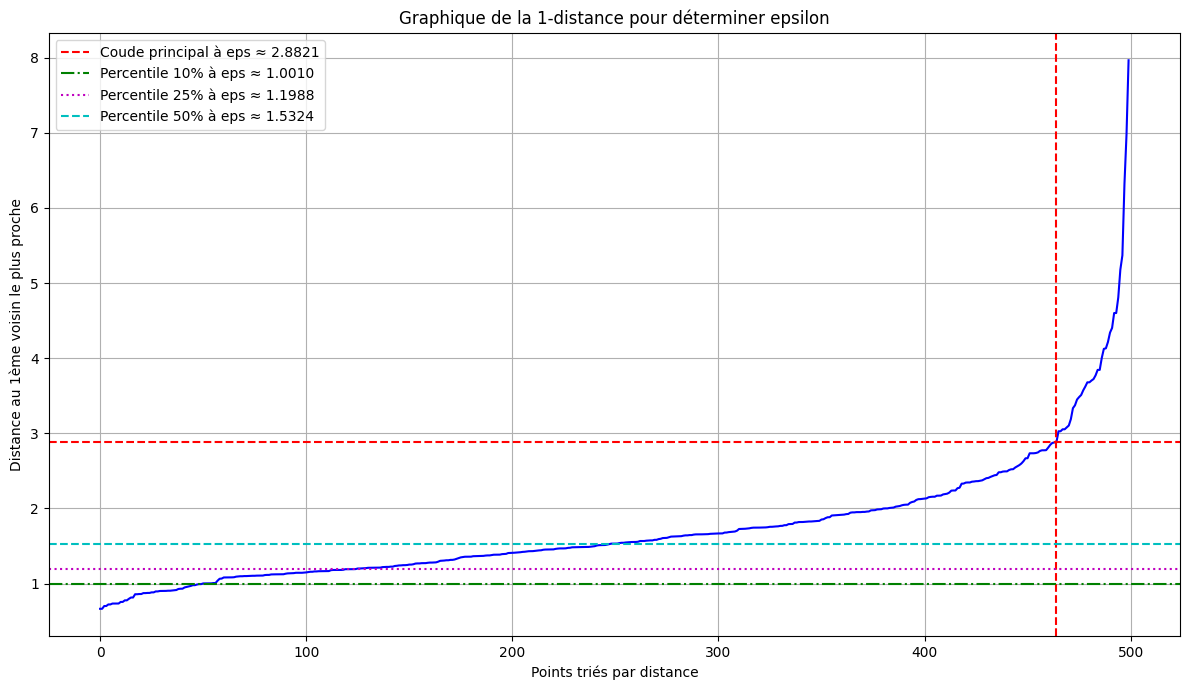


Test avec MinPts = 2


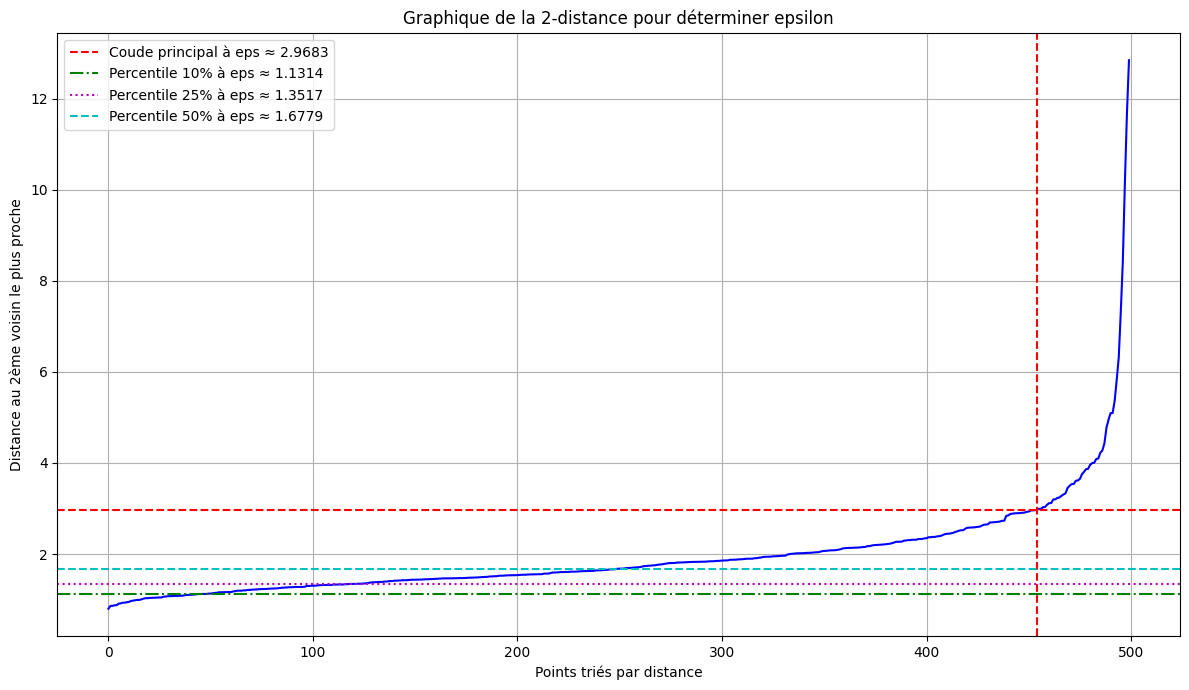


Test avec MinPts = 3


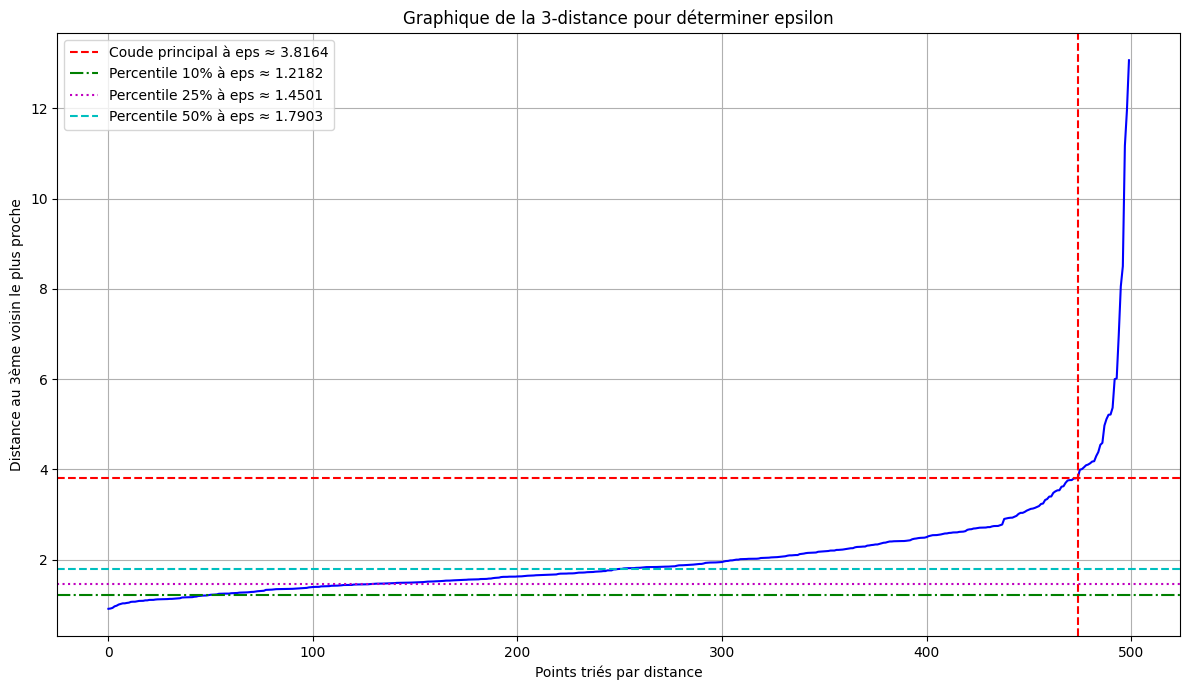


Test avec MinPts = 4


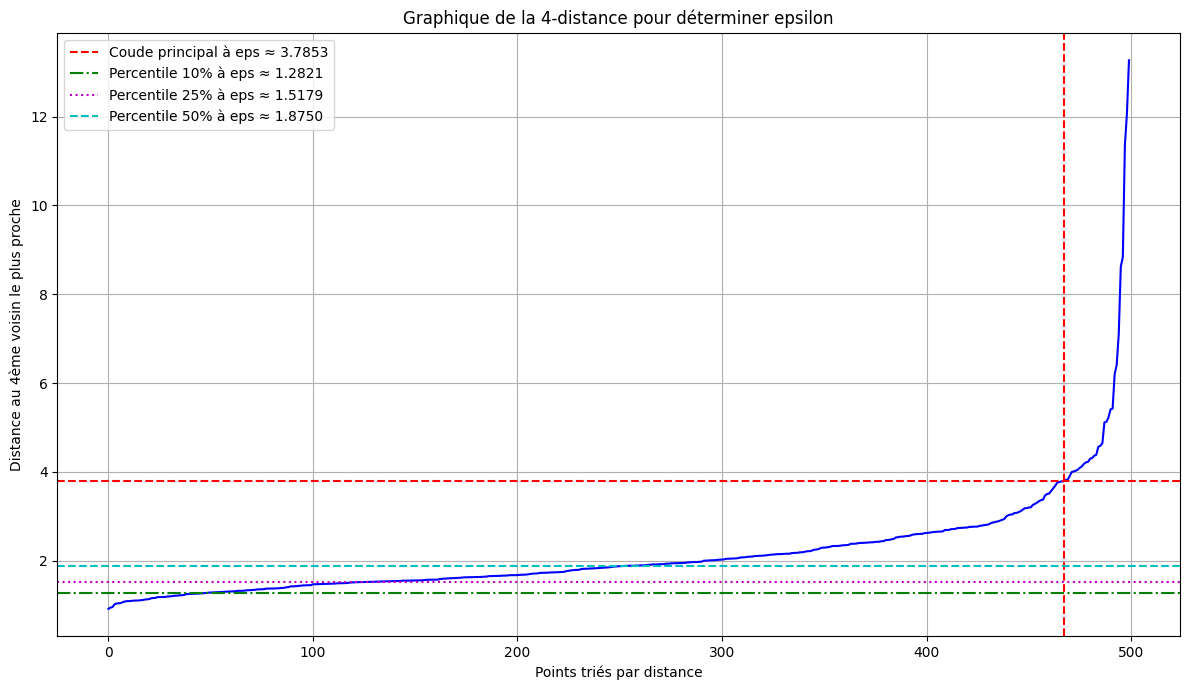


Test avec MinPts = 5


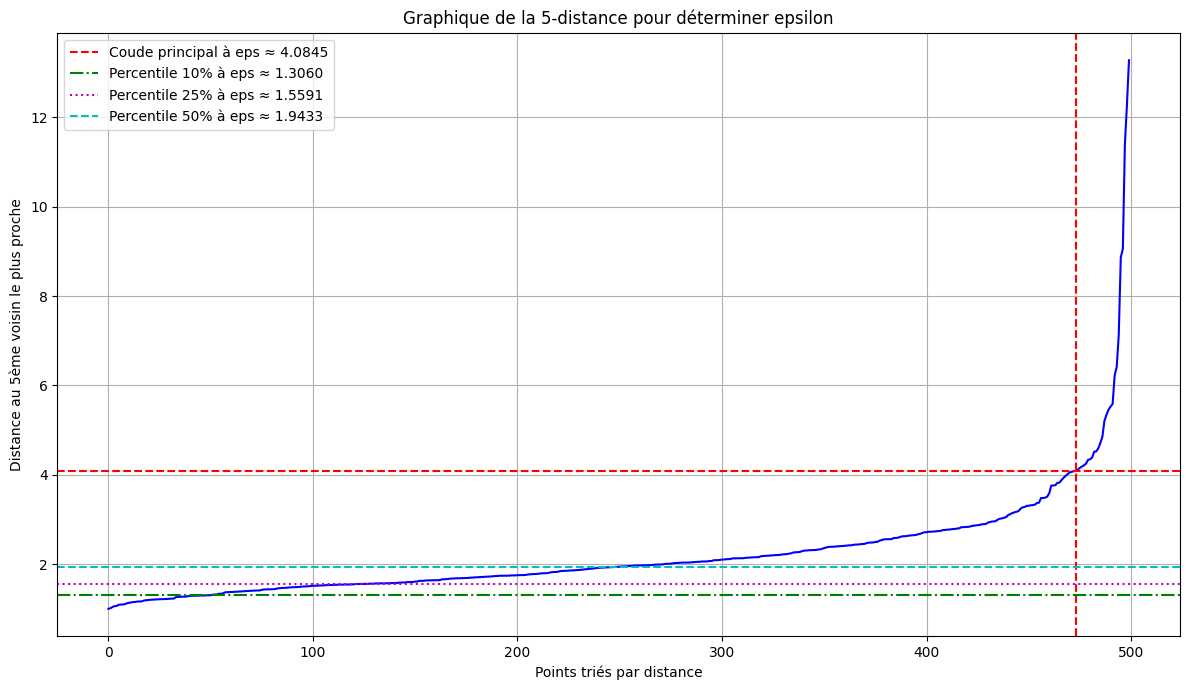


Test avec MinPts = 6


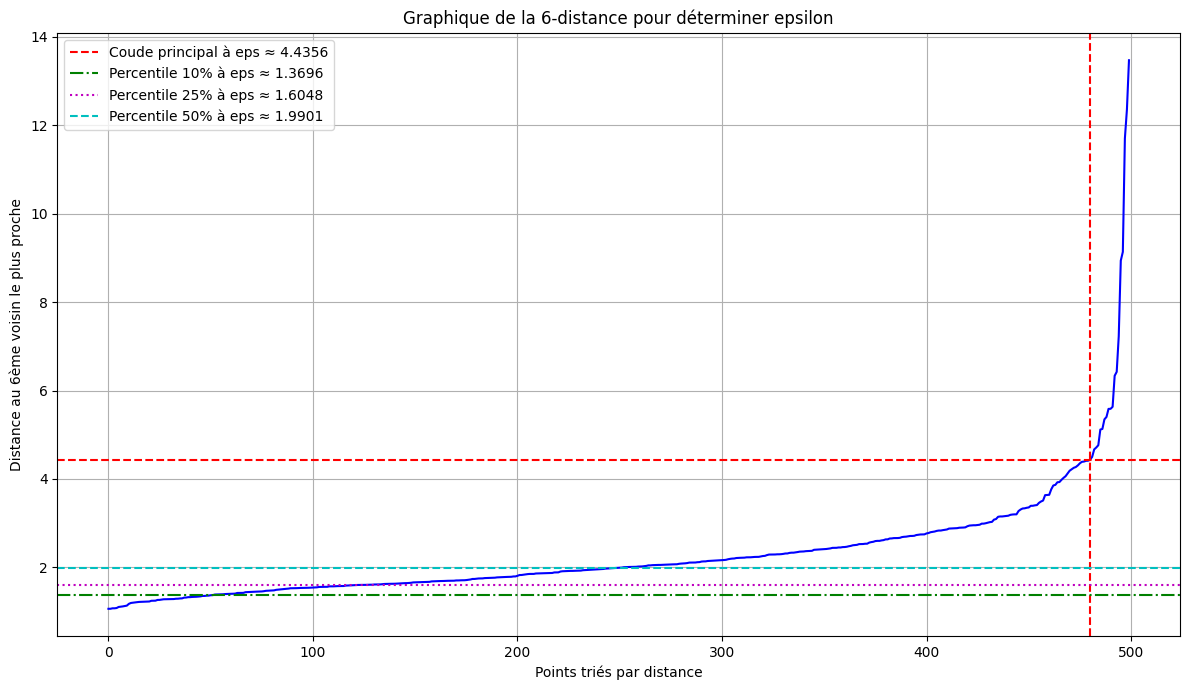


Test avec MinPts = 7


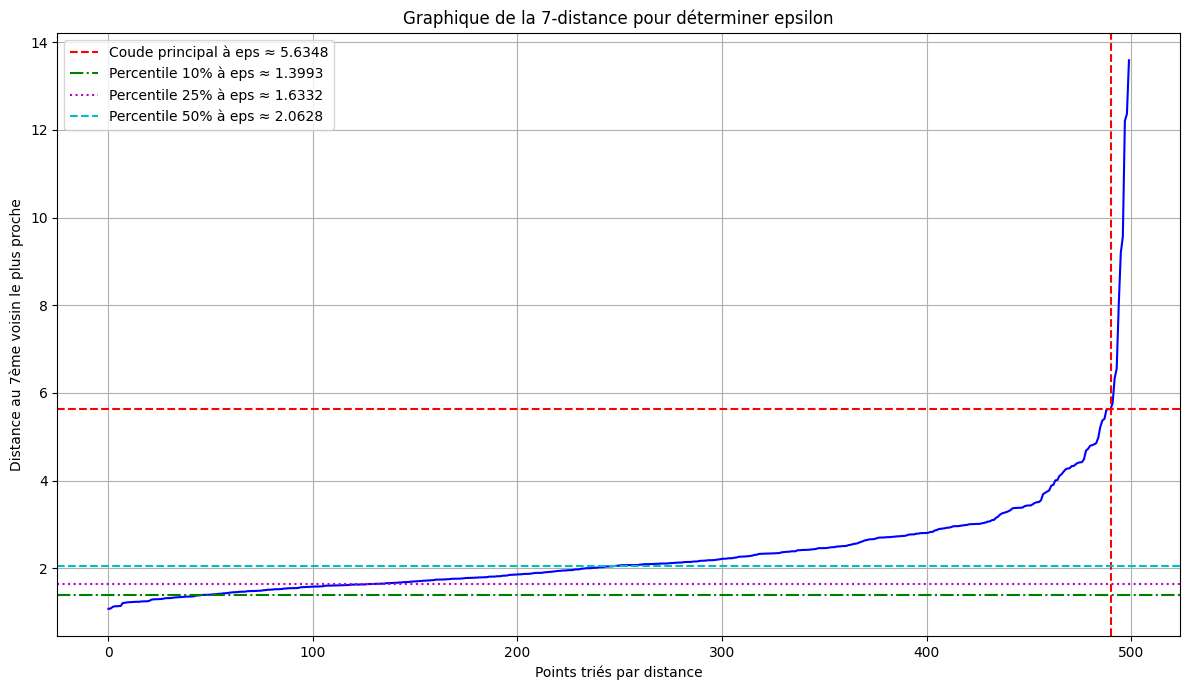


Test avec MinPts = 8


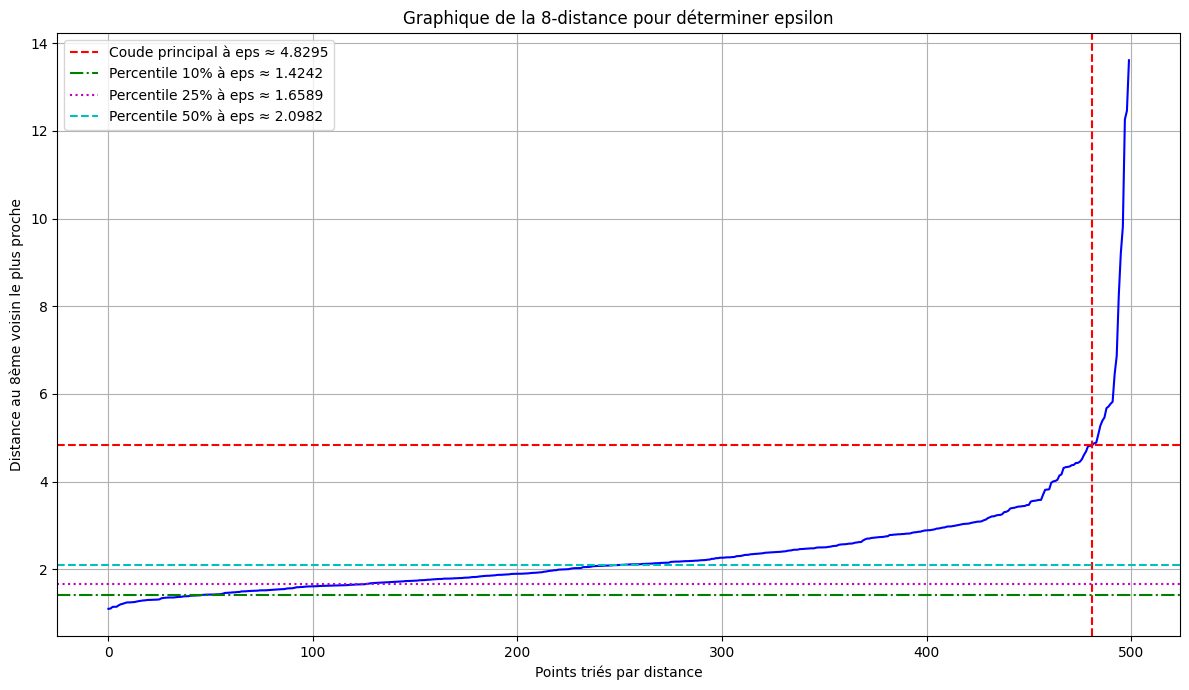


Test avec MinPts = 9


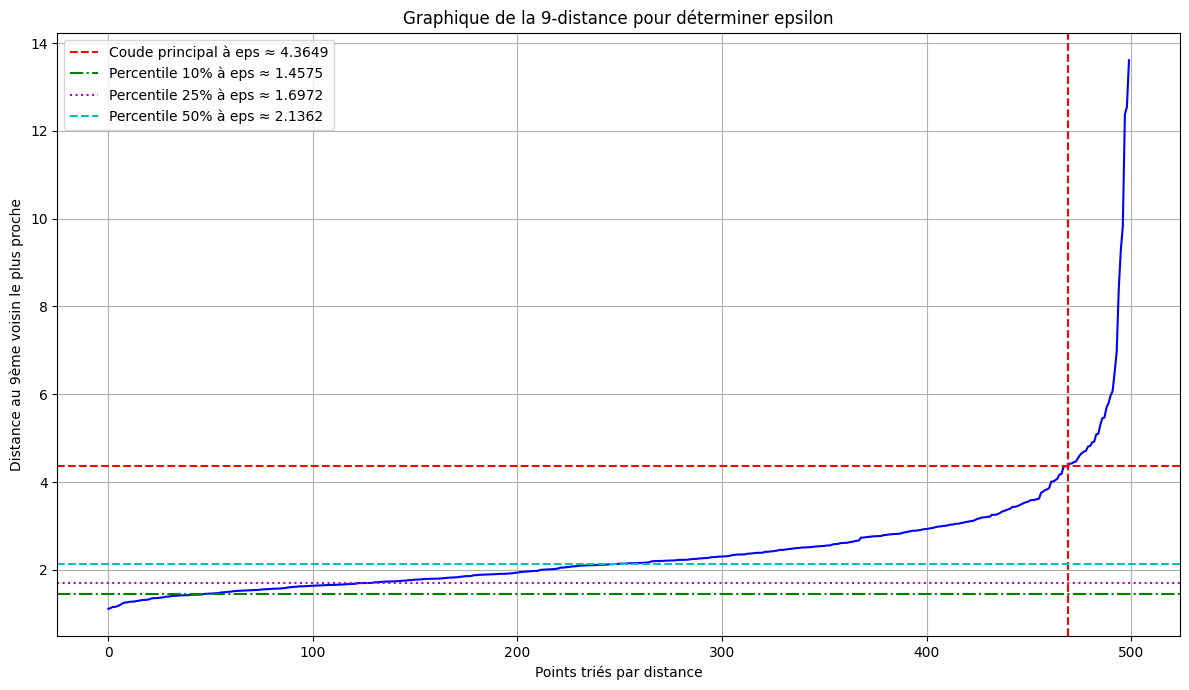


Test avec MinPts = 10
Aucune solution satisfaisante trouvée avec les critères actuels.
Essai avec des paramètres moins restrictifs...
Solution de repli trouvée: eps=1.1660, MinPts=2
  14 clusters, 78.2% de bruit

Équilibrage des clusters pour atteindre la cible...
Fusionné les clusters 8 et 13
Fusionné les clusters 5 et 10
Fusionné les clusters 3 et 12
Fusionné les clusters 5 et 8
Fusionné les clusters 3 et 5
Fusionné les clusters 6 et 9
Fusionné les clusters 1 et 2
Fusionné les clusters 3 et 7
Fusionné les clusters 3 et 11
Fusionné les clusters 0 et 1
Fusionné les clusters 0 et 4
Après équilibrage: 3 clusters, 78.2% de bruit
Tailles des clusters: [11, 94, 4]
Variance expliquée par les 2 premières composantes : 66.12%


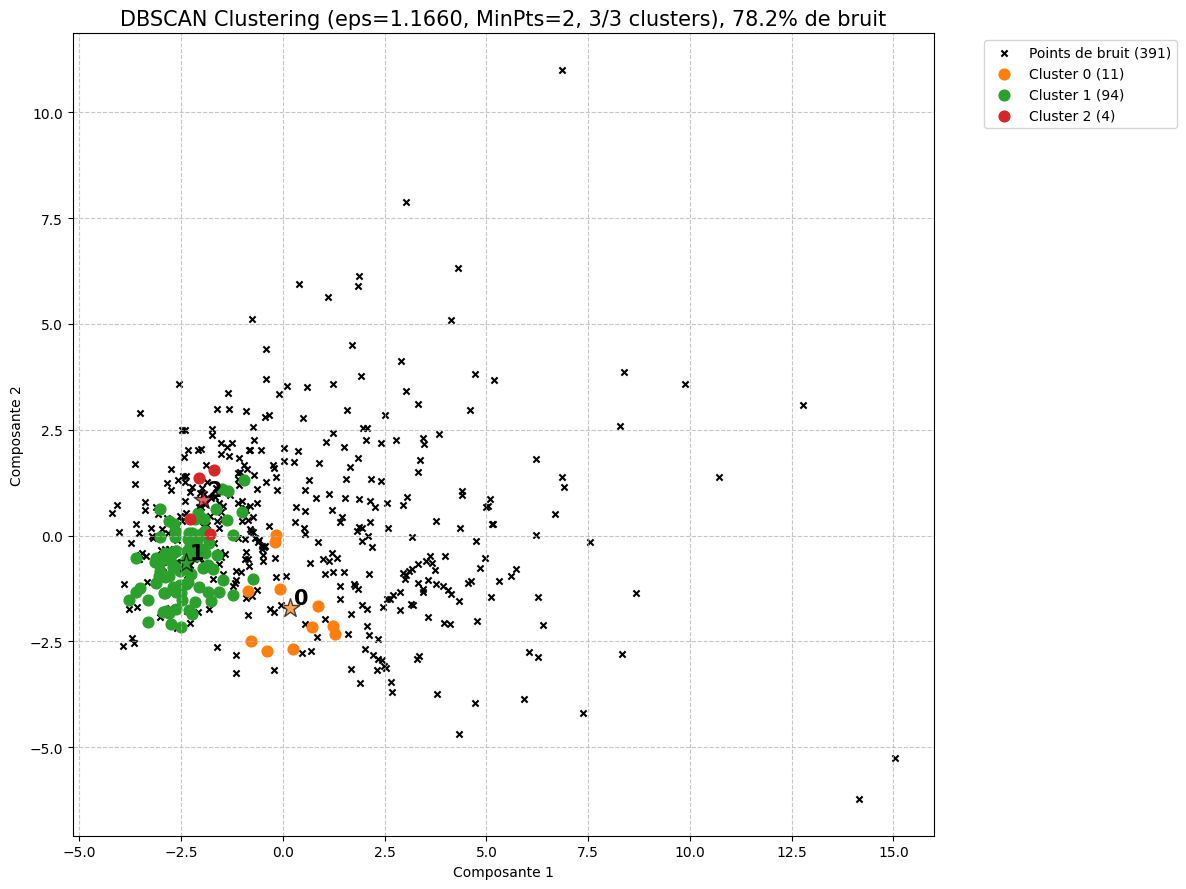


Statistiques des clusters (3 clusters, 78.2% bruit):

Cluster 0: 11 points (2.2%)
  Centre: [ 0.55916295  0.41580838  0.50550185  0.46120555 -0.07745351 -0.2658839
 -0.08630772  0.17187837 -0.48156382 -0.67295686 -0.11262816 -0.40803267
 -0.16968723 -0.02661779 -0.62684784 -0.6372568  -0.37688141 -0.2774103
  1.25064086]
  Écart-type: [5.28874355e-01 5.00283512e-01 5.02337982e-01 5.18082236e-01
 5.04856592e-01 4.23858131e-01 4.10937742e-01 4.67834318e-01
 4.29807385e-01 5.21865802e-01 3.09400502e-01 5.34828737e-01
 2.67923850e-01 2.37092537e-01 2.08883333e-01 2.00509486e-01
 1.67052303e-01 2.70536090e-01 2.22044605e-16]
  Min: [-0.22865835 -0.48221018 -0.28241931 -0.29696994 -1.01945708 -0.77424027
 -0.76118975 -0.54268389 -1.03184742 -1.37429402 -0.69819804 -1.20835375
 -0.65853226 -0.48469236 -0.98744826 -0.88437148 -0.67559197 -0.67776879
  1.25064086]
  Max: [ 1.15905877  1.29634726  1.12662625  1.08065006  0.73403992  0.40632018
  0.45721937  0.87763911  0.19250076  0.42901186  0

In [74]:
df, data = load_dataset("breast(1).csv")
labels = apply_dbscan_clustering(data, target_clusters=3, balance=True)